## orflib Library Examples

In [1]:
import orflib as orf
import numpy as np
import math
import os
import random

print("orflib version: {0}".format(orf.version()))
print("pid: {0}".format(os.getpid()))

orflib version: 0.2.0-debug
pid: 3920


In [2]:
name = "World"
print(orf.sayHello(name))

Hello World!


In [3]:
x = [1, 2, 3]
y = [4, 5]
op = orf.outerProd(x, y)
print(f'x: {x}\ny: {y}')
print(f'outerProd:\n{op}')

x: [1, 2, 3]
y: [4, 5]
outerProd:
[[ 4.  5.]
 [ 8. 10.]
 [12. 15.]]


### Analytic Prices

In [4]:
#fwdPrice
fwdpx = orf.fwdPrice(spot = 100, timetoexp = 1.0, intrate = 0.02, divyield = 0.04)
print('Forward price analytic solution')
print(f'Price={fwdpx:.4f}')

Forward price analytic solution
Price=98.0199


In [5]:
#digiBS
digi = orf.digiBS(payofftype = 1, spot = 100, timetoexp = 1.0, strike = 100,
                  intrate = 0.02, divyield = 0.04, volatility = 0.2)
print('Digital call using Black-Scholes analytic solution')
print(f'Price={digi:.4f}')

Digital call using Black-Scholes analytic solution
Price=0.4124


In [6]:
#euroBS
euro = orf.euroBS(payofftype = 1, spot = 100, timetoexp = 1.0, strike = 100,
                  intrate = 0.02, divyield = 0.04, volatility = 0.4)
print('European call using Black-Scholes analytic solution')
print(f'Price={euro:.4f}')

European call using Black-Scholes analytic solution
Price=14.4327


In [7]:
koFwdPrices=[]
for i in range(0,151,10):
    koFwd = orf.koFwd(spot = 100, KOLevel=i, timetoexp = 1.0, strike = 100, timetoKO=0.5,
                      intrate = 0.04, divyield = 0.02, volatility = 0.4)
    koFwdPrices.append((i, koFwd))

standardFwdPrice = orf.fwdPrice(spot = 100, timetoexp = 1.0, intrate = 0.04, divyield = 0.02)
standardFwdContract = math.exp(-0.04)*(standardFwdPrice-100)

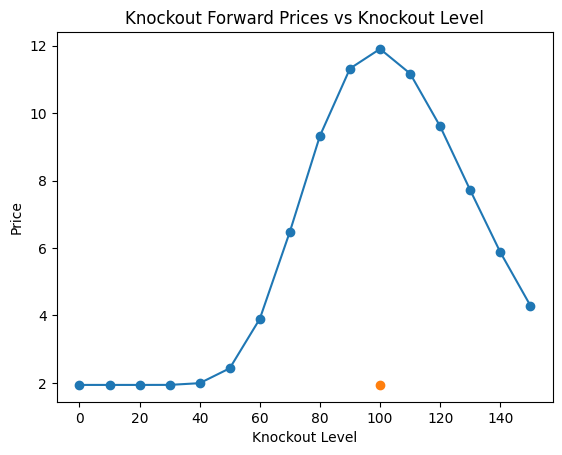

In [8]:
import matplotlib.pyplot as plt

# unzip the list of tuples
x_vals, y_vals = zip(*koFwdPrices)

plt.plot(x_vals, y_vals, marker="o", linestyle="-")
plt.plot(100, standardFwdContract, marker="o", linestyle="-")
plt.xlabel("Knockout Level")
plt.ylabel("Price")
plt.title("Knockout Forward Prices vs Knockout Level")
plt.show()

The knockout forward has it's highest price around the current spot value, where the price of the knockout is much higher than the standard forward. This knockout in effect becomes a european call option at 100 since the digital component has coefficient 0. 

The value of the call at 100, would be much higher than the corresponing value of the forward since we pay for the insurance premium. 

As the barrier moves away from 100, the price starts to fall. We can explain this on the upside by seeing that as the barrier becomes higher and higher, the chance of making money on this forward drops in likelihood, where you effectively don't want to pay for it's unlikely upside. On the downside, the barrier protection becomes less and less useful and so the price drops. At 0 this barrier effectively becomes worth nothing and the prices we reach is the same price as the standard forward itself.

In [9]:
qFwdPrices=[]
for i in range(-10,11,1):
    qFwdPrice = orf.qFwdPrice(spot=100, timetoexp=1, intrate=0.04, divyield=0.01, volFX=0.1, volAsset=0.4, corr=float(i)/10)
    qFwdPrices.append((float(i)/10, qFwdPrice))


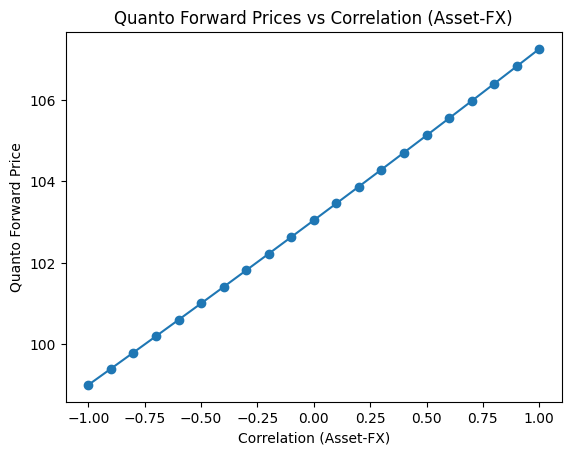

In [10]:
import matplotlib.pyplot as plt

# unzip the list of tuples
x_vals, y_vals = zip(*qFwdPrices)

plt.plot(x_vals, y_vals, marker="o", linestyle="-")
plt.xlabel("Correlation (Asset-FX)")
plt.ylabel("Quanto Forward Price")
plt.title("Quanto Forward Prices vs Correlation (Asset-FX)")
plt.show()

This is an increasing function. The economic reasoning here, can be thought of as follows:
Let us take a high correlation case: Here, if the asset does well, USDJPY will also appreciate, and the same in the down scenario. This leads to much higher variance on this contract and thus a higher risk premium.

On the flip side, with low correlation: Here, if the asset does well, USDJPY will depreciate, and vice versa implying the blow is cushioned for the seller of the contract. This makes it less risky and therefore cheaper.

In [42]:
S0 = 100.0               # initial spot
T = 1.0                  # time to maturity
r = 0.04                 # risk-free rate
q = 0.01                 # dividend yield
sigma = 0.40             # volatility
n = 10000                # number of samples


# --- Simulation ---
U = np.random.random_sample(n)       # uniform(0,1)
Z = [orf.normalInvCdf(u) for u in U]              # transform to standard normal
drift = (r - q - 0.5 * sigma**2) * T
diffusion = [sigma * z for z in Z]
S_T = [S0 * np.exp(drift + diff) for diff in diffusion]

# --- Statistics ---
sample_mean = np.mean(S_T)
sample_std = np.std(S_T, ddof=1)
se_mean = sample_std / np.sqrt(n)

# Exact theoretical mean
exact_mean = S0 * np.exp((r - q) * T)

# Difference in multiples of SE
z_multiple = np.abs(sample_mean - exact_mean) / se_mean

# --- Output ---
print(f"Sample size: {n}")
print(f"Sample mean: {sample_mean:.6f}")
print(f"Sample std dev: {sample_std:.6f}")
print(f"Std error of mean: {se_mean:.6f}")
print(f"Exact mean: {exact_mean:.6f}")
print(f"Difference (sample - exact): {sample_mean - exact_mean:.6f}")
print(f"Difference / Std error: {z_multiple:.3f}")

Sample size: 10000
Sample mean: 103.258920
Sample std dev: 72.024782
Std error of mean: 0.720248
Exact mean: 103.045453
Difference (sample - exact): 0.213467
Difference / Std error: 0.296
